# Team 13

Authors: Mathis Kriwoluzky, Lennart Koch.

This notebook is our own work. Any other sources have been clearly marked and cited.

All authors contributed equally.

---

## 1. Setup

In this notebook, we implement a neural network for classifying handwritten digits from the MNIST dataset.

We use:
- PyTorch for modeling and training
- torchvision for loading the dataset
- matplotlib & seaborn for visualization

In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import torch

BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## 2. Load Data

We use the MNIST dataset, which contains 28x28 grayscale images of handwritten digits (0–9).

The dataset is already split into training and test sets:
- Training data: 60,000 images
- Test data: 10,000 images

Transformation:
- Conversion of images into tensors (scaling to [0,1])

This transformation is necessary because neural networks require numerical input.

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# this dataset already comes split in train and test
transform = transforms.ToTensor()
train = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test  = datasets.MNIST(root="data", train=False, download=True, transform=transform)
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader  = DataLoader(test, batch_size=64, shuffle=False)

## 3. Data Exploration

The goal of this exploration is to:
- understand the structure of the data
- get an intuition for the variability of handwriting
- verify that the data is suitable for classification

### Sample counts

In [3]:
print("Train samples:", len(train))
print("Test samples:", len(test))

sample_img, sample_label = train[0]
print("Image shape:", sample_img.shape)

Train samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


### Visualization

The following examples show that:
- digits are written in different styles
- some classes are harder to distinguish (e.g., 4 vs 9)

→ This motivates the use of a machine learning model.

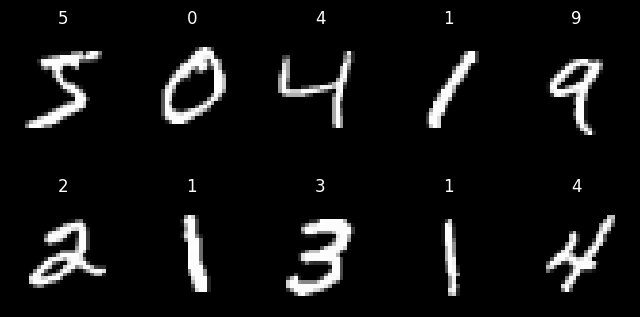

In [4]:
fig, axes = plt.subplots(2,5, figsize=(8,4))

for i, ax in enumerate(axes.flat):
    img, label = train[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(label)
    ax.axis('off')

plt.show()

### PCA Analysis

We use PCA to project the high dimensional image data 784D into 2D.

Goal:
- visualize the structure of the data
- check whether classes are linearly separable

Observation:
- clusters are visible
- however, classes are not perfectly separable

→ Conclusion:
A simple linear model may struggle → motivates more complex models.

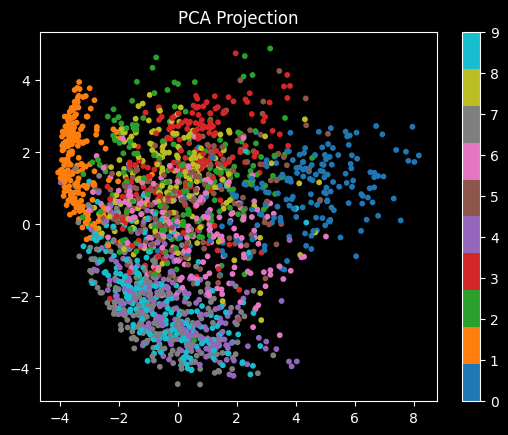

In [5]:
from sklearn.decomposition import PCA

# kleine Stichprobe
subset = torch.stack([train[i][0].view(-1) for i in range(2000)])
subset_labels = [train[i][1] for i in range(2000)]

pca = PCA(n_components=2)
X_pca = pca.fit_transform(subset)

plt.scatter(X_pca[:,0], X_pca[:,1], c=subset_labels, cmap='tab10', s=10)
plt.colorbar()
plt.title("PCA Projection")
plt.show()

## 4. Model

### Problem Definition
Multiclass classification (10 classes: digits 0–9)

### Baseline Model

We start with a simple linear model:
- Input: 784 features (pixels)
- Output: 10 classes

This model corresponds to multinomial logistic regression.

Advantage:
- Fast to train

Disadvantage:
- Can only model linear relationships

### Baseline model with linear classification

In [6]:
import torch.nn as nn

class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

model = BaselineModel().to(DEVICE)

### Loss Function and Optimizer

We use:
CrossEntropyLoss & Adam optimizer

This combination is a common default choice for neural networks.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 5. Training

During training:
1. Forward pass (prediction)
2. Compute loss
3. Backpropagation
4. Update weights

We store the loss per epoch to analyze the learning progress.

In [8]:
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

Epoch 1, Loss: 0.5430
Epoch 2, Loss: 0.3234
Epoch 3, Loss: 0.2951
Epoch 4, Loss: 0.2819
Epoch 5, Loss: 0.2740


### Interpretation of Loss Curve

A decreasing loss indicates:
- the model is learning
- predictions are improving

If the loss stagnates:
→ may indicate a model that is too simple or poorly chosen hyperparameters

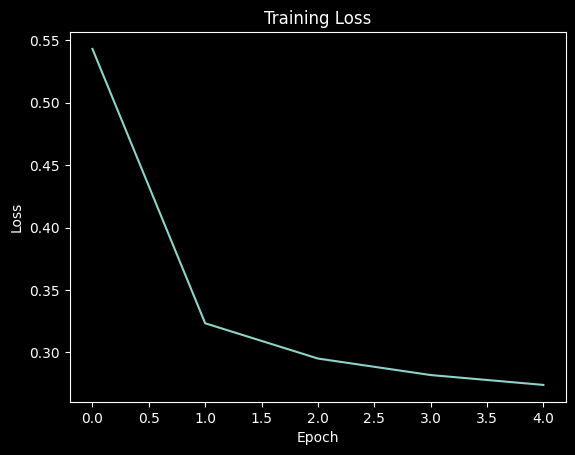

In [9]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## 6. Evaluation

For evaluation, we use:
- Accuracy
- Confusion Matrix

Why accuracy?
→ Simple and suitable for balanced datasets like MNIST

In [10]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.9254


### Interpretation of Confusion Matrix

The matrix shows:
- which classes are correctly predicted
- where the model makes mistakes

Typical observations:
- confusion between visually similar digits (e.g., 3 and 5)

→ Useful for diagnosing model weaknesses

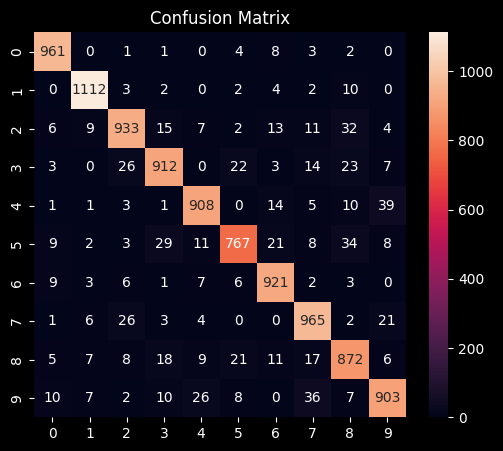

In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Why Test Data?

Test data is important because:
- it contains unseen data
- it simulates real-world usage

Without test data:
→ risk of overfitting
→ overly optimistic results

→ Test data measures generalization performance

## 7. Model Improvement

Motivation:
The baseline model is linear → limited expressiveness

Improvement:
- multiple layers (deep learning)
- nonlinear activation functions (ReLU)

Advantage:
→ the model can learn more complex patterns

In [12]:
class ImprovedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

model2 = ImprovedModel().to(DEVICE)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=LEARNING_RATE)

### Training

In [13]:
train_losses2 = []

for epoch in range(EPOCHS):
    model2.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer2.zero_grad()
        outputs = model2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer2.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses2.append(epoch_loss)

    print(f"[Improved] Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

[Improved] Epoch 1, Loss: 0.3467
[Improved] Epoch 2, Loss: 0.1433
[Improved] Epoch 3, Loss: 0.0983
[Improved] Epoch 4, Loss: 0.0725
[Improved] Epoch 5, Loss: 0.0566


### Evaluation

In [14]:
model2.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy2 = correct / total
print("Improved Accuracy:", accuracy2)

Improved Accuracy: 0.9754


### Model Comparison

We compare:
- Baseline accuracy
- Improved accuracy

Result:
The improved model achieves higher accuracy.

Interpretation:
- Nonlinear models are better suited for image data
- Multi-layer networks can capture complex structures

→ Confirms our hypothesis from the PCA analysis

In [15]:
print("Baseline Accuracy:", accuracy)
print("Improved Accuracy:", accuracy2)

Baseline Accuracy: 0.9254
Improved Accuracy: 0.9754
